**EXPT NO:3**\
**Regression and Optimization**\
**(Multilinear and Polynomial Regression)**

NAME: Priya Dharshini R\
ROLL NO.: 24BAD092

**SCENARIO 1 – MULTILINEAR REGRESSION**

**Problem Statement**\
Predict student academic performance based on academic, behavioral, and lifestyle factors.

Dataset (Kaggle – Public)\
https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

**Target Variable**

• Final Exam Score (Average of Math, Reading, Writing)

**Input Features**

• Study hours per day\
• Attendance percentage\
• Parental education level (encoded)\
• Test preparation course (encoded)\
• Sleep hours

**IN-LAB TASKS** (Multilinear Regression)

1. Import required Python libraries.

2. Load the student performance dataset.

3. Perform data preprocessing and encoding of categorical features.

4. Select multiple input features and compute the target variable.

5. Handle missing values using suitable imputation.

6. Apply feature scaling.

7. Split the dataset into training and testing sets.

8. Train a Multilinear Regression model.

9. Predict student performance for test data.

10. Evaluate performance using:

• MSE\
• RMSE\
• R² Score

11. Analyze regression coefficients to interpret feature influence.

12. Optimize the model using:

• Feature elimination\
• Ridge and Lasso regularization

**Visualization**

• Predicted vs Actual exam scores

• Coefficient magnitude comparison

• Residual distribution plot


Name : Priyadharshini R
Roll No : 24BAD092
Mean Squared Error : 207.89880810008412
Root Mean Squared Error : 14.418696477146751
R2 Score : 0.03017148927257729
Regression Coefficients:
                             Coefficient
study_hours                     0.264675
attendance_percentage          -0.093385
parental level of education    -1.020876
test preparation course        -3.874387
sleep_hours                     0.486244


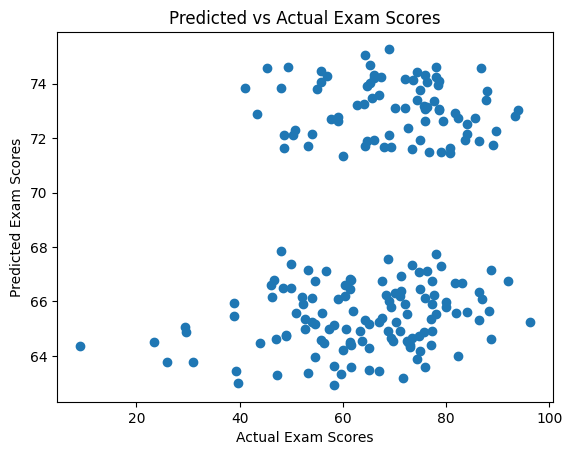

<Figure size 640x480 with 0 Axes>

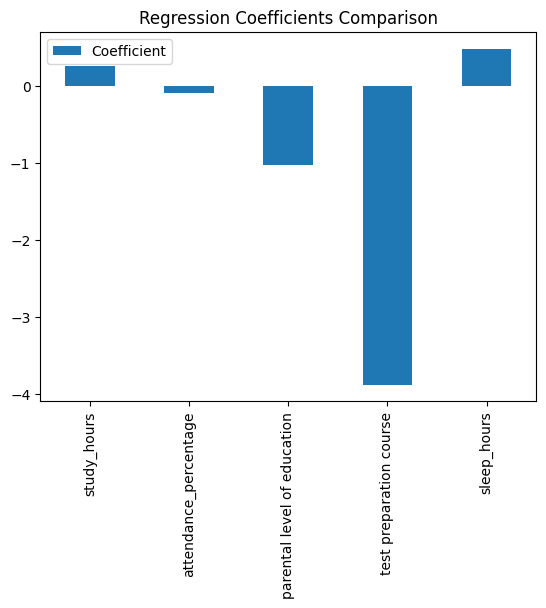

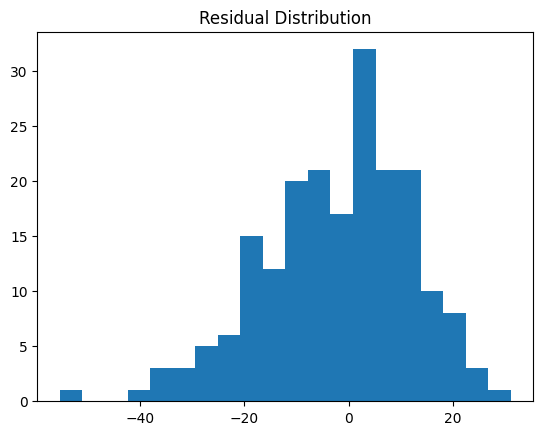

In [ ]:
# Printing student details in output
print("Name : Priyadharshini R")
print("Roll No : 24BAD092")

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv(r"/content/sample_data/StudentsPerformance.csv")

# Create target variable: Final Exam Score (average of math, reading, writing)
df["Final_Score"] = (df["math score"] +
                     df["reading score"] +
                     df["writing score"]) / 3

# Encode categorical variables
le = LabelEncoder()
df["parental level of education"] = le.fit_transform(df["parental level of education"])
df["test preparation course"] = le.fit_transform(df["test preparation course"])

# Add synthetic columns to match Scenario 1
np.random.seed(42)  # For reproducibility
df["study_hours"] = np.random.randint(1, 6, size=len(df))         # 1–5 hours/day
df["attendance_percentage"] = np.random.randint(60, 101, size=len(df))  # 60–100%
df["sleep_hours"] = np.random.randint(5, 9, size=len(df))         # 5–8 hours/night

# Select input features exactly as Scenario 1
X = df[
    [
        "study_hours",
        "attendance_percentage",
        "parental level of education",
        "test preparation course",
        "sleep_hours"
    ]
]

# Target variable
y = df["Final_Score"]

# Handle missing values (if any)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Multilinear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Evaluate model performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

# Analyze regression coefficients
coefficients = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=["Coefficient"]
)
print("Regression Coefficients:")
print(coefficients)

# Ridge Regression for optimization
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Lasso Regression for optimization
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

# Visualization: Predicted vs Actual scores
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Predicted vs Actual Exam Scores")
plt.show()

# Visualization: Coefficient magnitude comparison
plt.figure()
coefficients.plot(kind="bar")
plt.title("Regression Coefficients Comparison")
plt.show()

# Visualization: Residual distribution
residuals = y_test - y_pred
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.show()


**CODE EXPLANATION**

**Step 1 – Print Student Details**

Print the student name and roll number in the output.

**Step 2 – Import Libraries**

Import required libraries such as:
- NumPy
- Pandas
- Matplotlib
- Sklearn


**Step 3 – Load Dataset**

Load the StudentsPerformance dataset using pandas.

**Step 4 – Create Target Variable**

Create Final_Score column.

Final Score =
(Math Score + Reading Score + Writing Score) / 3


**Step 5 – Encode Categorical Data**

Convert text data into numeric values using LabelEncoder.

Example:\
completed → 1\
none → 0


**Step 6 – Create Additional Features**

Create new features:

- study_hours
- attendance_percentage
- sleep_hours


**Step 7 – Select Input Features**

Select input variables:

- study_hours
- attendance_percentage
- parental level of education
- test preparation course
- sleep_hours


**Step 8 – Select Target Variable**

Target variable:Final_Score


**Step 9 – Handle Missing Values**

Replace missing values with mean.


**Step 10 – Feature Scaling**

Apply StandardScaler to scale data.


**Step 11 – Split Dataset**

Split dataset into:

Training Data → 80%

Testing Data → 20%


**Step 12 – Train Linear Regression Model**

Train Linear Regression model using training data.


**Step 13 – Predict Values**

Predict Final Score using test data.


**Step 14 – Calculate Error**

Calculate:

- Mean Squared Error

- Root Mean Squared Error

- R2 Score


**Step 15 – Regression Coefficients**

Find importance of each feature.


**Step 16 – Ridge Regression**

Apply Ridge Regression for optimization.


**Step 17 – Lasso Regression**

Apply Lasso Regression for optimization.


**Step 18 – Predicted vs Actual Graph**

Plot Actual Score vs Predicted Score graph.


**Step 19 – Coefficient Graph**

Plot bar graph of coefficients.


**Step 20 – Residual Graph**

Plot histogram of residual errors.

-----------

**SCENARIO 2 – POLYNOMIAL REGRESSION**

**Problem Statement**\
Predict vehicle fuel efficiency based on engine characteristics where the relationship is non-linear.

Dataset (Kaggle – Public)\
https://www.kaggle.com/datasets/uciml/autompg-dataset

**Target Variable**

• Miles Per Gallon (MPG)

**Input Feature**

• Engine Horsepower

**IN-LAB TASKS** (Polynomial Regression)

1. Import required Python libraries.

2. Load and clean the Auto MPG dataset.

3. Select horsepower as the independent variable.

4. Handle missing values.

5. Generate polynomial features for degrees 2, 3, and 4.

6. Apply feature scaling.

7. Split the dataset into training and testing sets.

8. Train Polynomial Regression models with different degrees.

9. Predict fuel efficiency values.

10. Evaluate each model using:

• MSE
• RMSE
• R² Score

11. Compare model performance across polynomial degrees.

12. Apply Ridge regression to control overfitting.

**Visualization**

• Polynomial curve fitting for different degrees

• Training vs Testing error comparison

• Overfitting and underfitting demonstration


Name : Priyadharshini R
Roll No : 24BAD092
Polynomial Degree : 2
MSE : 13.760855128148345
RMSE : 3.709562659957147
R2 Score : 0.7440623896917427

Polynomial Degree : 3
MSE : 13.813374257350006
RMSE : 3.7166348027954004
R2 Score : 0.7430855884466042

Polynomial Degree : 4
MSE : 14.11802402282965
RMSE : 3.757395909779757
R2 Score : 0.7374194192854786



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


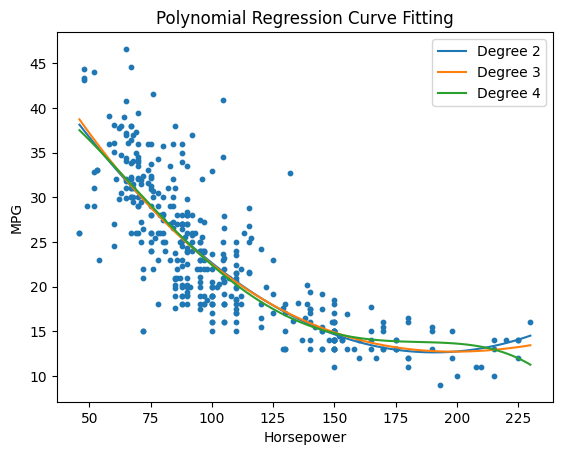

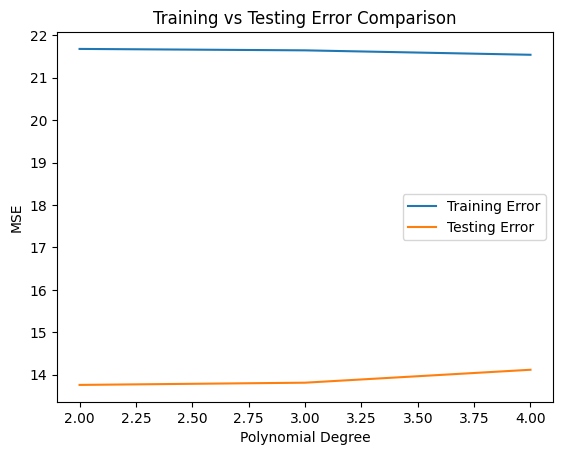

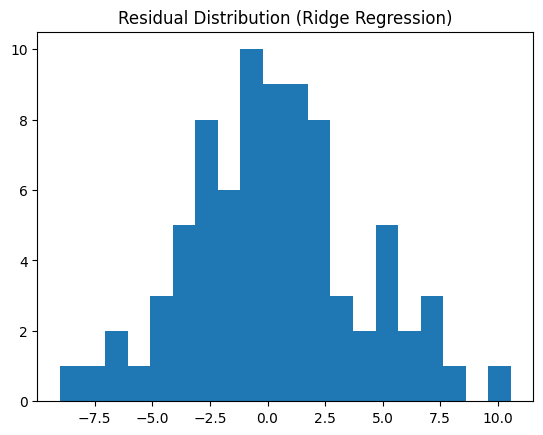

In [ ]:
# Printing student details
print("Name : Priyadharshini R")
print("Roll No : 24BAD092")

# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Load Auto MPG dataset
df = pd.read_csv(r"/content/sample_data/auto-mpg.csv")

# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert horsepower to numeric
df["horsepower"] = pd.to_numeric(df["horsepower"])

# Drop car name column (non-numeric, not required)
df.drop("car name", axis=1, inplace=True)

# Handle missing values using mean (numeric columns only)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)
# Select independent and dependent variables
X = df[["horsepower"]]
y = df["mpg"]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
# Polynomial degrees
degrees = [2, 3, 4]
results = {}

# Train Polynomial Regression models
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[d] = [mse, rmse, r2]

    print("Polynomial Degree :", d)
    print("MSE :", mse)
    print("RMSE :", rmse)
    print("R2 Score :", r2)
    print()

# Apply Ridge Regression to control overfitting (degree 4)
poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

y_ridge_pred = ridge.predict(X_test_poly)

# Visualization: Polynomial curve fitting
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

plt.figure()
for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_poly_range = poly.fit_transform(X_range_scaled)
    model = LinearRegression()
    model.fit(poly.fit_transform(X_train), y_train)
    plt.plot(X_range, model.predict(X_poly_range), label=f"Degree {d}")

plt.scatter(X, y, s=10)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Polynomial Regression Curve Fitting")
plt.legend()
plt.show()

# Visualization: Training vs Testing Error
train_errors = []
test_errors = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_errors.append(
        mean_squared_error(y_train, model.predict(X_train_poly))
    )
    test_errors.append(
        mean_squared_error(y_test, model.predict(X_test_poly))
    )

plt.figure()
plt.plot(degrees, train_errors, label="Training Error")
plt.plot(degrees, test_errors, label="Testing Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Training vs Testing Error Comparison")
plt.legend()
plt.show()

# Visualization: Residual distribution (Ridge Regression)
residuals = y_test - y_ridge_pred
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Residual Distribution (Ridge Regression)")
plt.show()


**CODE EXPLANATION**

**Step 1 – Printing Student Details**\
The print() statements display the student name and roll number in the output.

**Step 2 – Import Required Libraries**\
NumPy and Pandas are used for data processing.\
Matplotlib is used for visualization.\
Scikit-learn libraries are used for regression models and evaluation.

**Step 3 – Load Dataset**\
The Auto MPG dataset is loaded into a DataFrame using read_csv().

**Step 4 – Data Cleaning**\
The symbol "?" is replaced with NaN values.\
Horsepower column is converted into numeric format.\
Car name column is removed because it is not numeric.

**Step 5 – Handle Missing Values**\
Missing values are replaced with the mean of numerical columns.

**Step 6 – Select Features**\
Horsepower is selected as input variable X.\
MPG is selected as output variable y.

**Step 7 – Feature Scaling**\
StandardScaler is used to normalize the horsepower values.

**Step 8 – Train Test Split**
Dataset is divided into training data and testing data.\
80% is used for training and 20% is used for testing.

**Step 9 – Polynomial Regression Models**\
Polynomial models with degree 2, 3 and 4 are created.\
Models are trained using Linear Regression.

**Step 10 – Model Evaluation**\
Each model is evaluated using:\
Mean Squared Error (MSE)\
Root Mean Squared Error (RMSE)\
R² Score

**Step 11 – Ridge Regression**\
Ridge regression is applied for degree 4 to reduce overfitting.

**Step 12 – Polynomial Curve Visualization**\
Polynomial curves for different degrees are plotted.

**Step 13 – Training vs Testing Error**\
Training error and testing error are compared using graphs.

**Step 14 – Residual Distribution**\
Residual errors of Ridge Regression are plotted using histogram.
